In [2]:
#basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# stats
from scipy.stats import chisquare
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import dunnett
from statsmodels.stats.proportion import proportion_confint

#others
import math
import os
from pathlib import Path
from IPython.display import HTML, display
import ipywidgets as widgets
import pickle


In [3]:
import sys
sys.path.append("src")   # VERY IMPORTANT

In [34]:
BASE_DIR = Path.cwd()
data_path1 = os.path.join(BASE_DIR, 'data','upworthy-archive-confirmatory-packages-03.12.2020.csv')
data_path2 = os.path.join(BASE_DIR, 'data','upworthy-archive-exploratory-packages-03.12.2020.csv')
data_path3 = os.path.join(BASE_DIR, 'data','upworthy-archive-holdout-packages-03.12.2020.csv')
data_path4 = os.path.join(BASE_DIR, 'data','upworthy-archive-undeployed-packages.01.12.2021.csv')

In [35]:
BASE_DIR

PosixPath('/home/d/Documents/Other_projects/Headline_Engagement_Analysis')

In [36]:
df_confirmatory=pd.read_csv(data_path1)
df_exploratory=pd.read_csv(data_path2)
df_holdout=pd.read_csv(data_path3)
df_undeployed=pd.read_csv(data_path4)

/tmp/ipykernel_134642/1820728600.py:1: DtypeWarning: Columns (0: square) have mixed types. Specify dtype option on import or set low_memory=False.
  df_confirmatory=pd.read_csv(data_path1)
/tmp/ipykernel_134642/1820728600.py:4: DtypeWarning: Columns (0: square) have mixed types. Specify dtype option on import or set low_memory=False.
  df_undeployed=pd.read_csv(data_path4)


In [37]:
#df_confirmatory=pd.read_csv("upworthy-archive-confirmatory-packages-03.12.2020.csv")
#df_exploratory=pd.read_csv("upworthy-archive-exploratory-packages-03.12.2020.csv")
#df_holdout=pd.read_csv("upworthy-archive-holdout-packages-03.12.2020.csv")
#df_undeployed=pd.read_csv("upworthy-archive-undeployed-packages.01.12.2021.csv")

In [38]:
df_confirmatory.head()

,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,11,2014-11-20 11:33:26.475,2016-04-02 16:25:54.046,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,"Let’s See … Hire Cops, Pay Teachers, Buy Books...",<p>Iff you start with the basic fact that inno...,let-s-see-hire-cops-pay-teachers-buy-books-for...,546dce659ad54ec65b000041,3118,8,0.1,False,False,NaN,NaN,201446
1,12,2014-11-20 15:00:01.032,2016-04-02 16:25:54.128,546e01d626714c6c4400004e,Things that matter. Pass 'em on.,People Sent This Lesbian Questions And Her Rai...,<p>I'll be honest. I've wondered about 7.</p>,people-sent-this-lesbian-questions-and-her-rai...,546d1b4bfd3617f091000041,4587,130,55.8,False,False,NaN,NaN,201446
2,13,2014-11-20 11:33:51.973,2016-04-02 16:25:54.069,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,$3 Million Is What It Takes For A State To Leg...,<p>Iff you start with the basic fact that inno...,3-million-is-what-it-takes-for-a-state-to-lega...,546dce659ad54ec65b000041,3017,19,26.9,False,False,NaN,NaN,201446
3,14,2014-11-20 11:34:12.107,2016-04-02 16:25:54.049,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,The Fact That Sometimes Innocent People Are Ex...,<p>Iff you start with the basic fact that inno...,the-fact-that-sometimes-innocent-people-are-ex...,546dce659ad54ec65b000041,2974,26,100.0,True,False,NaN,NaN,201446
4,15,2014-11-20 11:34:33.935,2016-04-02 16:25:54.072,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,Reason #351 To End The Death Penalty: It Costs...,<p>Iff you start with the basic fact that inno...,reason-351-to-end-the-death-penalty-it-costs-3...,546dce659ad54ec65b000041,3050,10,0.2,False,False,NaN,NaN,201446


In [39]:
# join all df togeher
df_all = pd.concat([df_confirmatory, df_exploratory, df_holdout, df_undeployed],
    keys=["confirmatory", "exploratory", "holdout", "undeployed"]
     ).reset_index(level=0).rename(columns={"level_0": "dataset_id"}).reset_index(drop=True)
# delete _id
df_all = df_all.drop("_id", axis=1)
df_all

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,confirmatory,11.0,2014-11-20 11:33:26.475,2016-04-02 16:25:54.046,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,"Let’s See … Hire Cops, Pay Teachers, Buy Books...",<p>Iff you start with the basic fact that inno...,let-s-see-hire-cops-pay-teachers-buy-books-for...,546dce659ad54ec65b000041,3118.0,8.0,0.1,False,False,NaN,NaN,201446.0
1,confirmatory,12.0,2014-11-20 15:00:01.032,2016-04-02 16:25:54.128,546e01d626714c6c4400004e,Things that matter. Pass 'em on.,People Sent This Lesbian Questions And Her Rai...,<p>I'll be honest. I've wondered about 7.</p>,people-sent-this-lesbian-questions-and-her-rai...,546d1b4bfd3617f091000041,4587.0,130.0,55.8,False,False,NaN,NaN,201446.0
2,confirmatory,13.0,2014-11-20 11:33:51.973,2016-04-02 16:25:54.069,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,$3 Million Is What It Takes For A State To Leg...,<p>Iff you start with the basic fact that inno...,3-million-is-what-it-takes-for-a-state-to-lega...,546dce659ad54ec65b000041,3017.0,19.0,26.9,False,False,NaN,NaN,201446.0
3,confirmatory,14.0,2014-11-20 11:34:12.107,2016-04-02 16:25:54.049,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,The Fact That Sometimes Innocent People Are Ex...,<p>Iff you start with the basic fact that inno...,the-fact-that-sometimes-innocent-people-are-ex...,546dce659ad54ec65b000041,2974.0,26.0,100.0,True,False,NaN,NaN,201446.0
4,confirmatory,15.0,2014-11-20 11:34:33.935,2016-04-02 16:25:54.072,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,Reason #351 To End The Death Penalty: It Costs...,<p>Iff you start with the basic fact that inno...,reason-351-to-end-the-death-penalty-it-costs-3...,546dce659ad54ec65b000041,3050.0,10.0,0.2,False,False,NaN,NaN,201446.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229044,undeployed,NaN,2014-11-20 03:48:54.29,2016-04-02 16:31:40.693,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b49545240e55400005d,0.0,0.0,0.0,False,False,NaN,NaN,NaN
229045,undeployed,NaN,2014-11-20 03:50:04.032,2016-04-02 16:31:40.696,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b4bfd3617f091000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN
229046,undeployed,NaN,2014-11-20 03:50:51.753,2016-04-02 16:25:53.976,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8fd36177d3300004b,0.0,0.0,0.0,False,False,NaN,NaN,NaN
229047,undeployed,NaN,2014-11-20 03:51:04.482,2016-04-02 16:25:53.979,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8badeb52b15000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN


# Data Description
* **upworthy-archive-confirmatory-packages-03.12.2020.csv** — confirmatory experiments designed to validate prior findings
* **upworthy-archive-exploratory-packages-03.12.2020.csv** — exploratory experiments designed to generate hypotheses
* **upworthy-archive-holdout-packages-03.12.2020.csv** — holdout data for validation and robustness checks
* **upworthy-archive-undeployed-packages-01.12.2021.csv** — experiments that were not deployed to production

Each database have several experiments. An experiment is the **clickability_test_id** and an arm (what is been tested in the experiment) is the **eyecatcher_id**. For each experiment we are testing different eyecatcher_id. So it is a A/B/n test

Each dataset includes fields such as:

* **headline** — text of the tested headline
* **impressions** — number of times the headline was shown
* **clicks** — number of times the headline was clicked
* **eyecatcher_id** — ID for images used in experiments
* **clickability_test_id**— experiment identifier

### Questions than can be Investigated

1. Do headlines containing numbers perform better than those without?
2. Does framing a headline as a question increase engagement?
3. Are shorter headlines more effective than longer ones?
4. Can you analyis every single experiment


### Practicalities 
Analyze the provided data and provide insights using appropriate statistical methods, including:

* Two-proportion z-tests for comparing CTR between groups
* Chi-square tests for categorical comparisons
* Exploratory vs confirmatory replication checks
  
Make sure the solution includes:

* Clear data exploration steps
* Properly explained statistical methodology
* Concise interpretations of results for business stakeholders
* The focus is not only on producing results but also on showing the reasoning and methodology behind A/B testing and its role in decision-making

# Preprocessing

In [40]:
df_confirmatory.info()

<class 'pandas.DataFrame'>
RangeIndex: 105551 entries, 0 to 105550
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            105551 non-null  int64  
 1   created_at            105551 non-null  str    
 2   updated_at            105551 non-null  str    
 3   clickability_test_id  105551 non-null  str    
 4   excerpt               94335 non-null   str    
 5   headline              105551 non-null  str    
 6   lede                  105485 non-null  str    
 7   slug                  105551 non-null  str    
 8   eyecatcher_id         105420 non-null  str    
 9   impressions           105551 non-null  int64  
 10  clicks                105551 non-null  int64  
 11  significance          105551 non-null  float64
 12  first_place           105551 non-null  bool   
 13  winner                105551 non-null  bool   
 14  share_text            14632 non-null   str    
 15  square     

In [41]:
# change databs
#date_format = "%Y-%m-%d %H:%M:%S.%f"

df_all["created_at"] = pd.to_datetime(df_all["created_at"], format="mixed")
df_all["updated_at"] = pd.to_datetime(df_all["updated_at"], format="mixed")

In [42]:
df_all["CTR"]=df_all["clicks"]/df_all["impressions"]

In [43]:
df_all

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week,CTR
0,confirmatory,11.0,2014-11-20 11:33:26.475,2016-04-02 16:25:54.046,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,"Let’s See … Hire Cops, Pay Teachers, Buy Books...",<p>Iff you start with the basic fact that inno...,let-s-see-hire-cops-pay-teachers-buy-books-for...,546dce659ad54ec65b000041,3118.0,8.0,0.1,False,False,NaN,NaN,201446.0,0.002566
1,confirmatory,12.0,2014-11-20 15:00:01.032,2016-04-02 16:25:54.128,546e01d626714c6c4400004e,Things that matter. Pass 'em on.,People Sent This Lesbian Questions And Her Rai...,<p>I'll be honest. I've wondered about 7.</p>,people-sent-this-lesbian-questions-and-her-rai...,546d1b4bfd3617f091000041,4587.0,130.0,55.8,False,False,NaN,NaN,201446.0,0.028341
2,confirmatory,13.0,2014-11-20 11:33:51.973,2016-04-02 16:25:54.069,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,$3 Million Is What It Takes For A State To Leg...,<p>Iff you start with the basic fact that inno...,3-million-is-what-it-takes-for-a-state-to-lega...,546dce659ad54ec65b000041,3017.0,19.0,26.9,False,False,NaN,NaN,201446.0,0.006298
3,confirmatory,14.0,2014-11-20 11:34:12.107,2016-04-02 16:25:54.049,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,The Fact That Sometimes Innocent People Are Ex...,<p>Iff you start with the basic fact that inno...,the-fact-that-sometimes-innocent-people-are-ex...,546dce659ad54ec65b000041,2974.0,26.0,100.0,True,False,NaN,NaN,201446.0,0.008742
4,confirmatory,15.0,2014-11-20 11:34:33.935,2016-04-02 16:25:54.072,546dd17e26714c82cc00001c,Things that matter. Pass 'em on.,Reason #351 To End The Death Penalty: It Costs...,<p>Iff you start with the basic fact that inno...,reason-351-to-end-the-death-penalty-it-costs-3...,546dce659ad54ec65b000041,3050.0,10.0,0.2,False,False,NaN,NaN,201446.0,0.003279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229044,undeployed,NaN,2014-11-20 03:48:54.290,2016-04-02 16:31:40.693,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b49545240e55400005d,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN
229045,undeployed,NaN,2014-11-20 03:50:04.032,2016-04-02 16:31:40.696,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1b4bfd3617f091000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN
229046,undeployed,NaN,2014-11-20 03:50:51.753,2016-04-02 16:25:53.976,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8fd36177d3300004b,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN
229047,undeployed,NaN,2014-11-20 03:51:04.482,2016-04-02 16:25:53.979,546d64a626714c1ad900000e,Things that matter. Pass 'em on.,People Ask This Lesbian Questions And Her Rais...,<p>I'll be honest. I've wondered about 7.</p>,people-ask-this-lesbian-questions-and-her-rais...,546d1af8badeb52b15000041,0.0,0.0,0.0,False,False,NaN,NaN,NaN,NaN


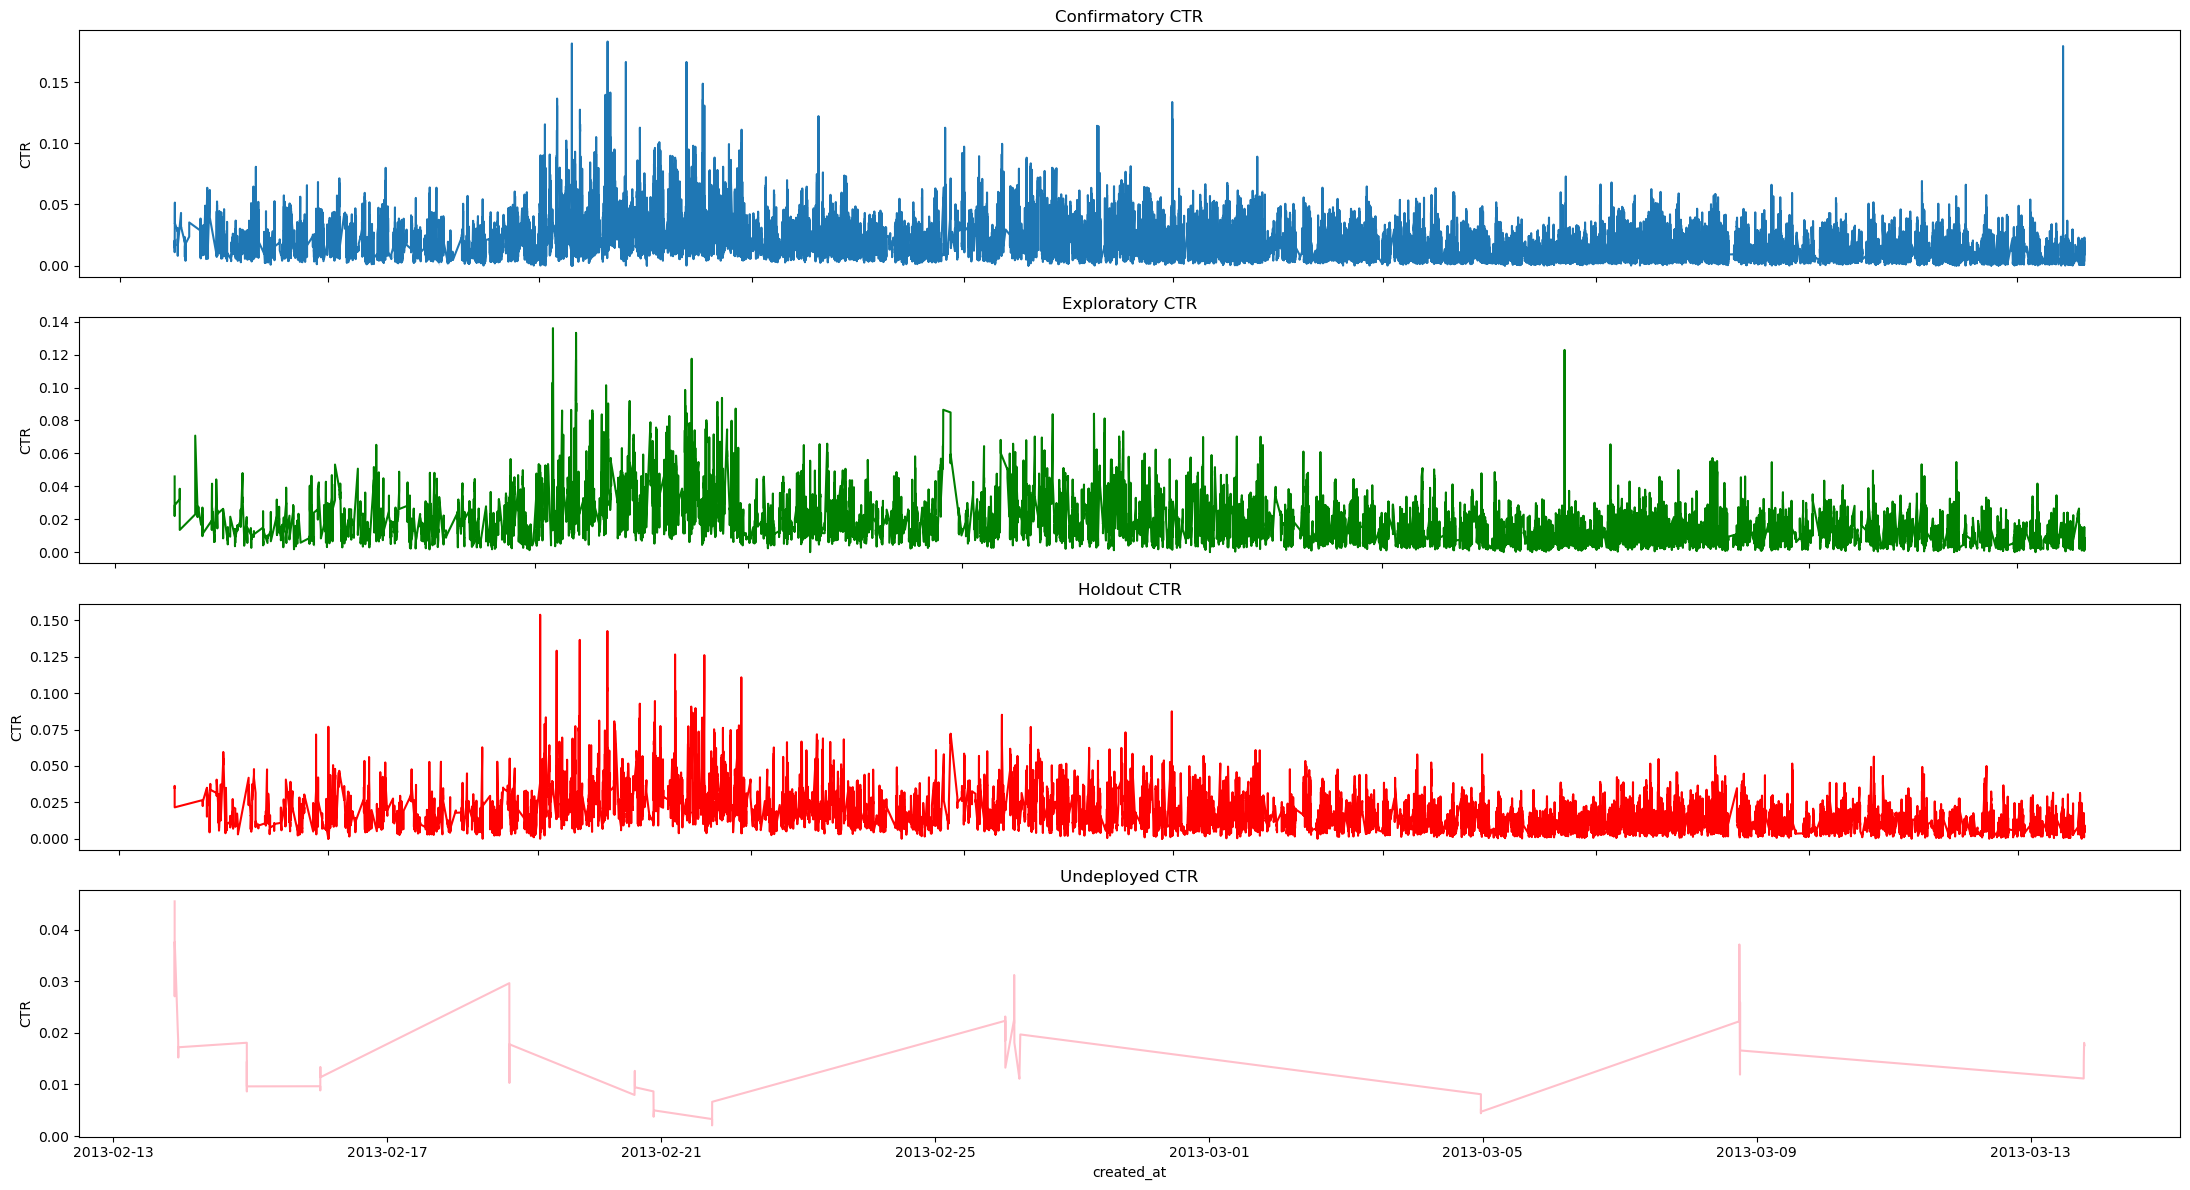

In [44]:
#plt.figure(figsize=(20, 4))
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(22, 12))
sns.lineplot(data=df_all[df_all["dataset_id"]=="confirmatory"], x="created_at", y="CTR", ax=ax1)
sns.lineplot(data=df_all[df_all["dataset_id"]=="exploratory"], x="created_at", y="CTR", ax=ax2, color="green")
sns.lineplot(data=df_all[df_all["dataset_id"]=="holdout"], x="created_at", y="CTR", ax=ax3, color="red")
sns.lineplot(data=df_all[df_all["dataset_id"]=="undeployed"], x="created_at", y="CTR", ax=ax4, color="pink")


ax1.set_title("Confirmatory CTR")
ax2.set_title("Exploratory CTR")
ax3.set_title("Holdout CTR")
ax4.set_title("Undeployed CTR")

for ax in [ax1, ax2, ax3]:
    ax.set(xlabel=None)          # Removes the "created_at" label text
    ax.set_xticklabels([])       # Removes the dates/times numbers completely

plt.savefig('experiment_vs_time.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

* There seems to be an issue around 2013-07 to 2013-10
* There are some spike in the data. Not sure what to do with it

In [45]:
# summary of data 
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0               78232
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  21127
 headline                     9
 lede                     58171
 slug                         0
 eyecatcher_id              182
 impressions              54211
 clicks                   54211
 significance                 0
 first_place                  0
 winner                       0
 share_text              189266
 square                  178893
 test_week                78232
 CTR                      78175
 dtype: int64,
 229049)

In [46]:
# Filters the DataFrame to show only the duplicate rows
duplicate_rows = df_all[df_all.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [dataset_id, Unnamed: 0, created_at, updated_at, clickability_test_id, excerpt, headline, lede, slug, eyecatcher_id, impressions, clicks, significance, first_place, winner, share_text, square, test_week, CTR]
Index: []


In [47]:
# delete empty eyecatcher_id
df_all.dropna(subset=['eyecatcher_id'],inplace=True)
# delete empty headline
df_all.dropna(subset=['headline'],inplace=True)
# delele rows with empty impressions
df_all.dropna(subset=['impressions'],inplace=True)
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0               24020
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  17217
 headline                     0
 lede                      6258
 slug                         0
 eyecatcher_id                0
 impressions                  0
 clicks                       0
 significance                 0
 first_place                  0
 winner                       0
 share_text              146299
 square                  124681
 test_week                24020
 CTR                      23963
 dtype: int64,
 174655)

In [48]:
# delete all zeros for impressions
df_all = df_all[df_all['impressions'] != 0]
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0                  57
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  16027
 headline                     0
 lede                       104
 slug                         0
 eyecatcher_id                0
 impressions                  0
 clicks                       0
 significance                 0
 first_place                  0
 winner                       0
 share_text              129792
 square                  101017
 test_week                   57
 CTR                          0
 dtype: int64,
 150692)

In [49]:
# remove dates btw 2013-June and 2013-Oct
df_all = df_all[~((df_all["created_at"] >= "2013-06-25") &(df_all["created_at"] <= "2013-10-01"))]
df_all.isna().sum(),len(df_all)

(dataset_id                   0
 Unnamed: 0                  57
 created_at                   0
 updated_at                   0
 clickability_test_id        57
 excerpt                  14128
 headline                     0
 lede                       103
 slug                         0
 eyecatcher_id                0
 impressions                  0
 clicks                       0
 significance                 0
 first_place                  0
 winner                       0
 share_text              114689
 square                  101017
 test_week                   57
 CTR                          0
 dtype: int64,
 135589)

In [50]:
# fix number of clicks when it is zero. Haldane-Anscombe Correction
# not needed for Bayesian statistics

# Create a mask for rows where clicks are 0
zero_clicks_mask = df_all['clicks'] == 0

#Add 0.5 to the clicks column for those rows
df_all.loc[zero_clicks_mask, 'clicks'] += 0.5

#Add 1.0 to impressions for those rows to balance the success/failure ratio
if 'impressions' in df_all.columns:
    df_all.loc[zero_clicks_mask, 'impressions'] += 1.0

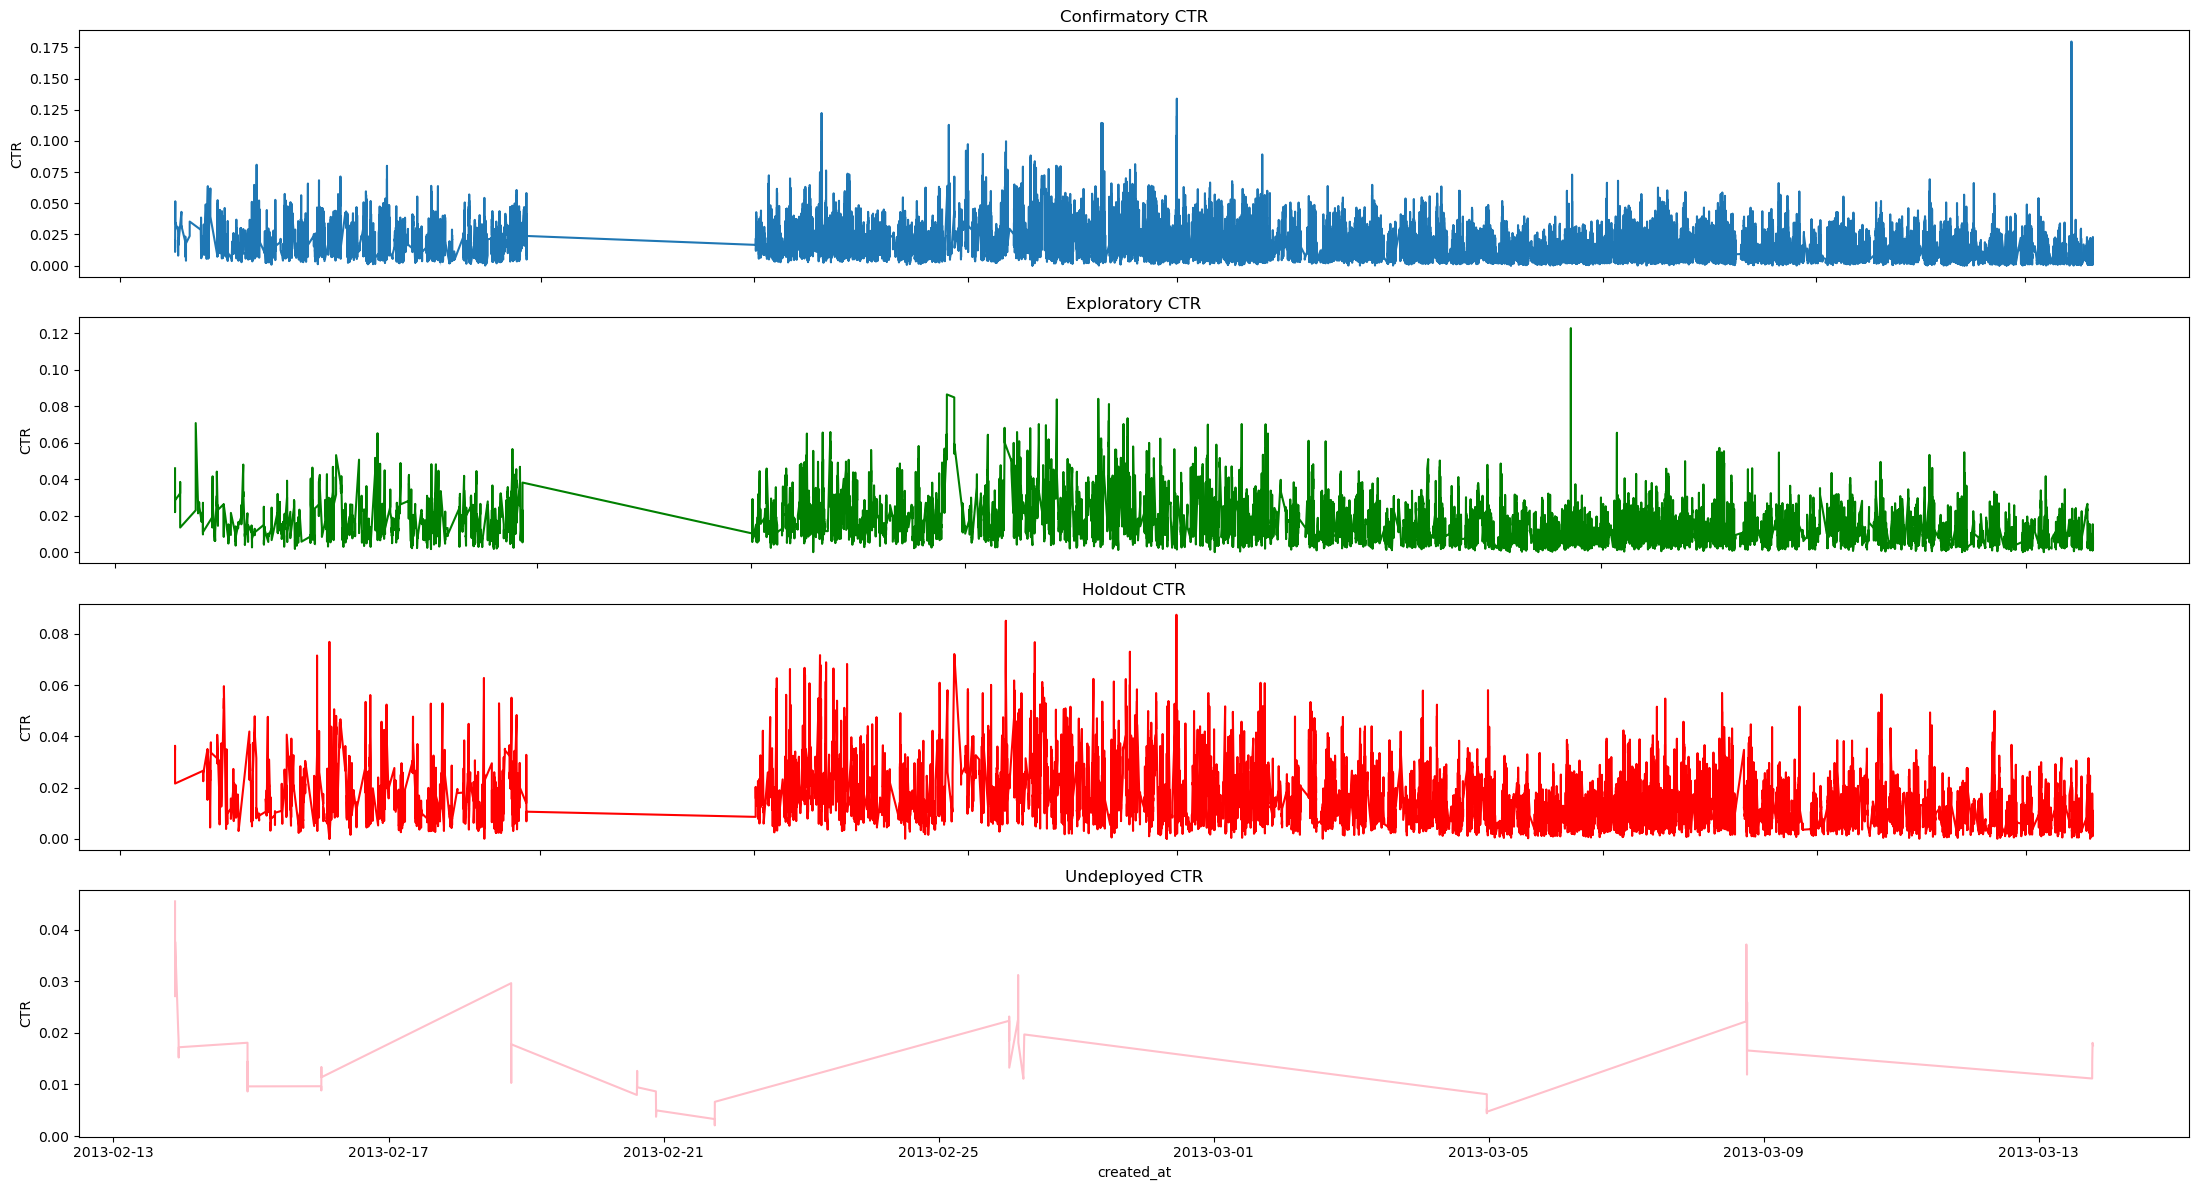

In [51]:
#plot again
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(22, 12))
sns.lineplot(data=df_all[df_all["dataset_id"]=="confirmatory"], x="created_at", y="CTR", ax=ax1)
sns.lineplot(data=df_all[df_all["dataset_id"]=="exploratory"], x="created_at", y="CTR", ax=ax2, color="green")
sns.lineplot(data=df_all[df_all["dataset_id"]=="holdout"], x="created_at", y="CTR", ax=ax3, color="red")
sns.lineplot(data=df_all[df_all["dataset_id"]=="undeployed"], x="created_at", y="CTR", ax=ax4, color="pink")


ax1.set_title("Confirmatory CTR")
ax2.set_title("Exploratory CTR")
ax3.set_title("Holdout CTR")
ax4.set_title("Undeployed CTR")

for ax in [ax1, ax2, ax3]:
    ax.set(xlabel=None)          # Removes the "created_at" label text
    ax.set_xticklabels([])       # Removes the dates/times numbers completely

plt.savefig('experiment_vs_time_processed.png', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [55]:
# count number of words/ or numbers in the headline

df_all["word_count_headline"] = (df_all["headline"].str.findall(r"[a-zA-Z]+").str.len().fillna(0).astype(int))
df_all["num_count_headline"] = (df_all["headline"].str.findall(r"\d+").str.len().fillna(0).astype(int))
df_all["word_num_count_headline"] =  df_all["word_count_headline"]+  df_all["num_count_headline"]

In [56]:
# check if headline has a question mark?
df_all["any_questions"] = df_all["headline"].astype(str).str.contains(r"\?").astype(int)
# check if headline has any number 
df_all["any_number"] = 0
df_all.loc[df_all["num_count_headline"] > 0, "any_number"] = 1

# EDA

In [57]:
cat_list=["dataset_id", "first_place", "winner", "any_questions" , "any_number"]

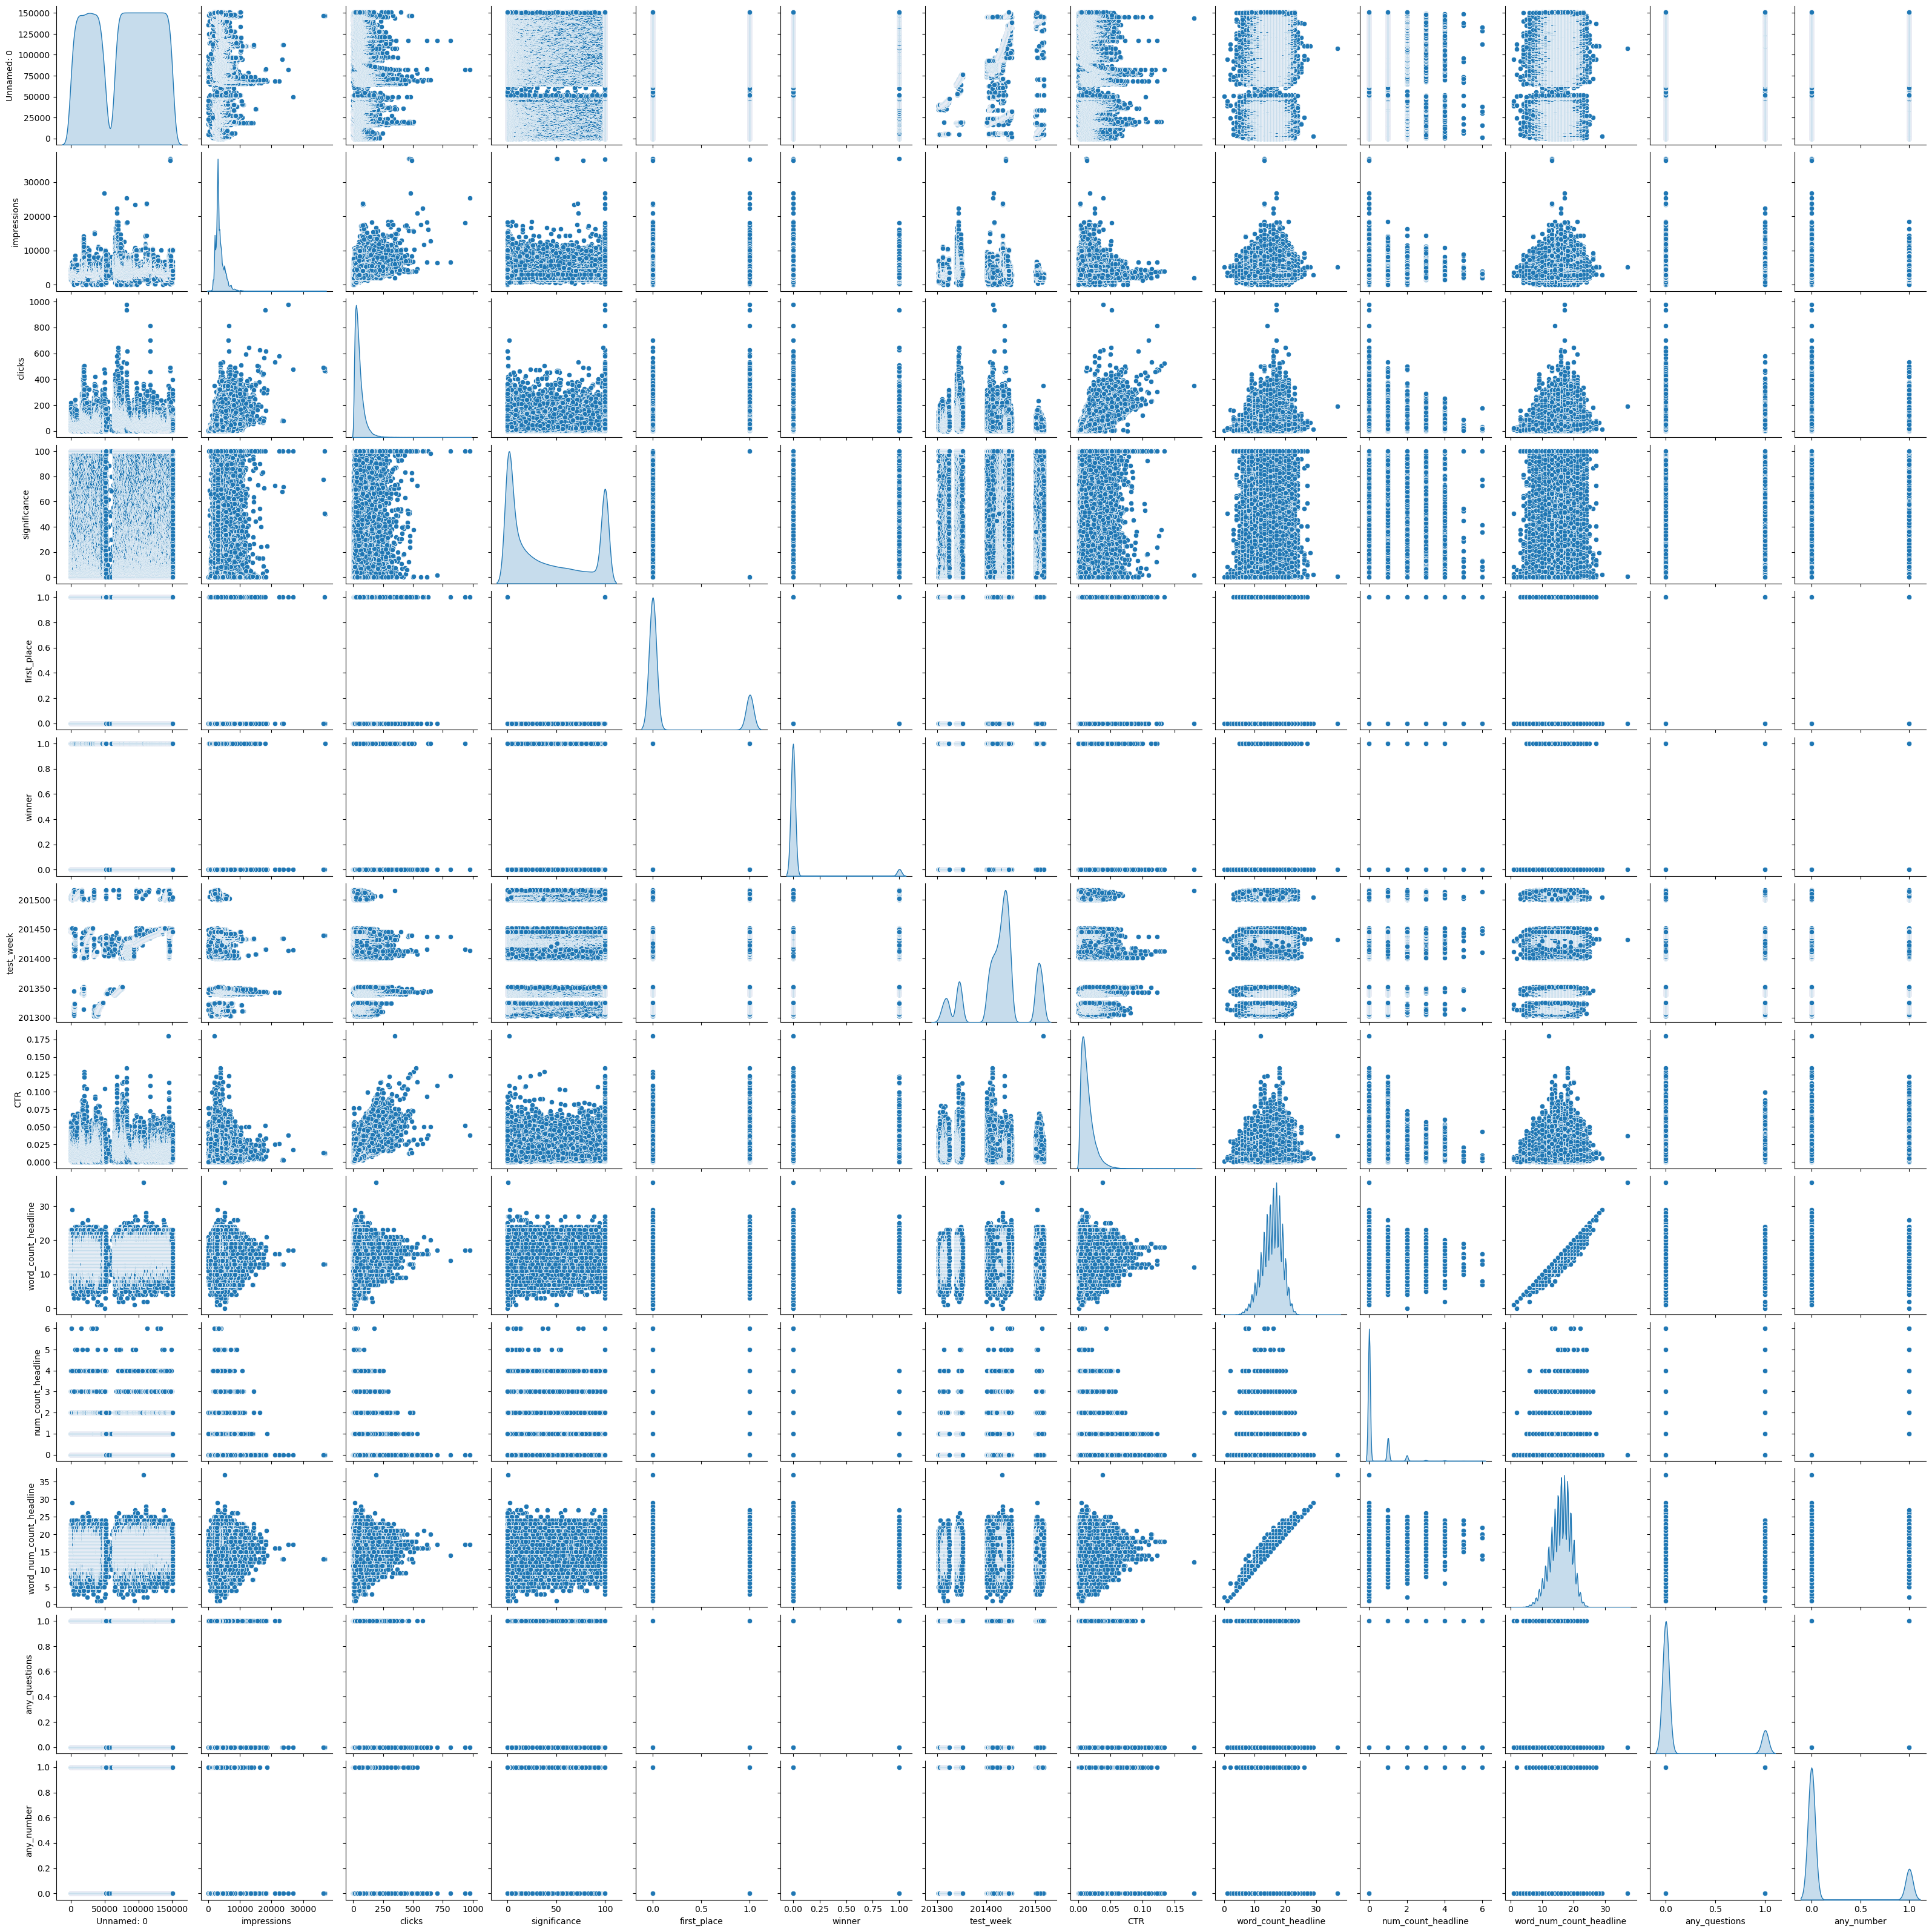

In [27]:
sns.pairplot(df_all, diag_kind='kde') 

It lookslike there is a sweet spot for the word count. 10 to 25
CTR increase with number of clicks

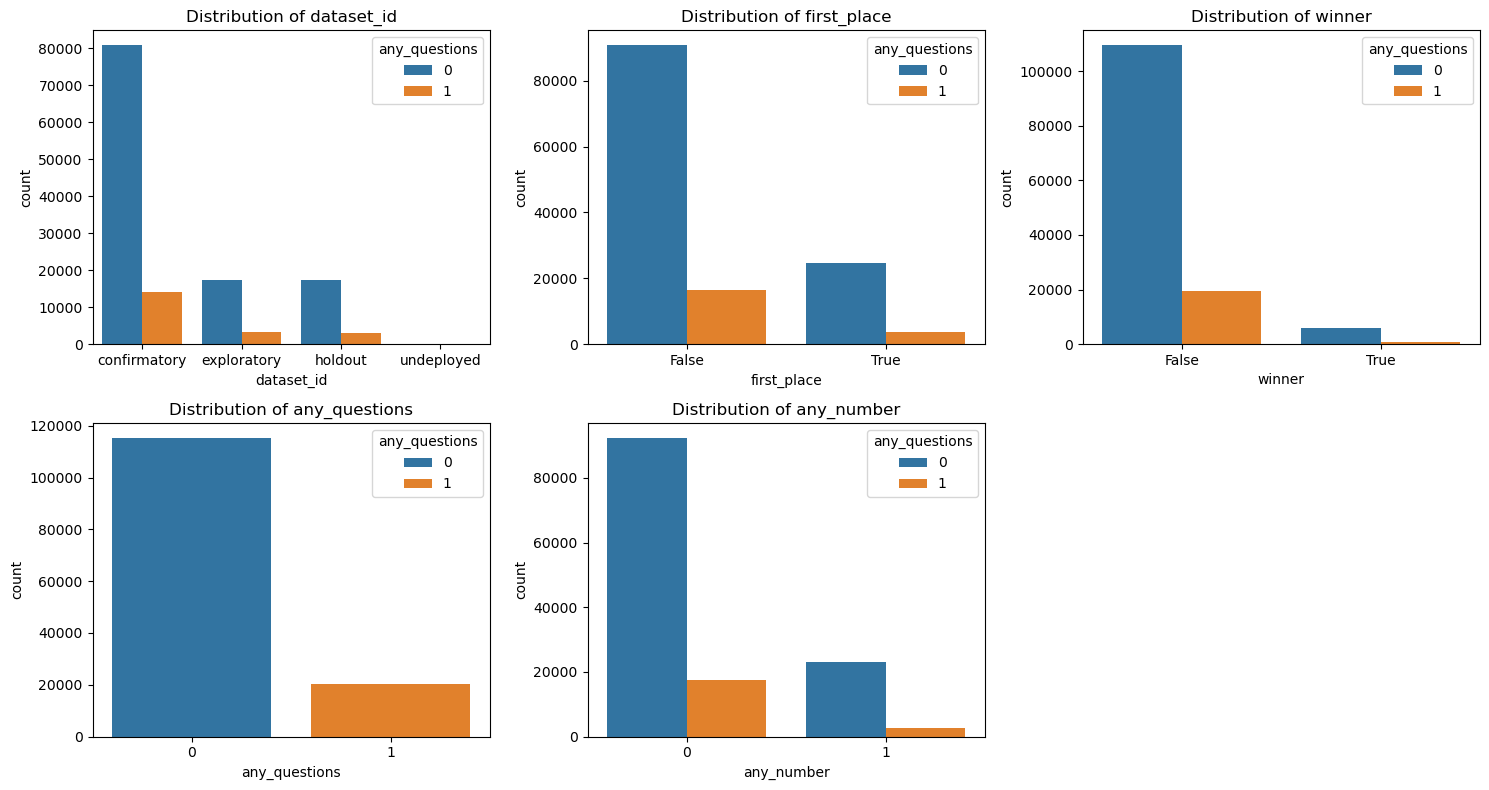

In [58]:
cat_list=["dataset_id", "first_place", "winner", "any_questions" , "any_number"]
# make a count plot of cat data
num_cols = 3  # Set how many columns you want in your grid
num_rows = math.ceil(len(cat_list) / num_cols)

#Initialize the dynamic grid canvas
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))

#Flatten axes to easily loop over them with a single index
axes = axes.flatten()

for i, col in enumerate(cat_list):
    sns.countplot(x = col, data=df_all, hue="any_questions", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)


#Hide any empty subplots if your grid has leftover cells
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [59]:
df_all.describe().T

,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,135532.0,77729.130028,0.0,34613.75,83049.5,116932.25,150816.0,45184.62659
created_at,135589,2014-07-11 12:43:24.665303,2013-01-24 14:57:06,2014-03-24 00:55:24.991000,2014-08-22 04:09:12.210000,2014-11-17 12:49:26.631000,2015-04-30 02:03:39.370000,NaN
updated_at,135589,2016-04-02 19:34:06.813254,2016-04-02 16:24:06.823000,2016-04-02 16:26:16.906000,2016-04-02 16:28:56.610000,2016-04-02 16:30:44.550000,2016-12-06 17:26:09.876000,NaN
impressions,135589.0,3616.706149,13.0,2790.0,3159.0,4145.0,36908.0,1462.016564
clicks,135589.0,50.111211,0.5,23.0,39.0,64.0,975.0,41.086423
significance,135589.0,40.266814,0.0,2.5,24.7,84.5,100.0,39.661818
test_week,135532.0,201427.413371,201303.0,201412.0,201433.0,201446.0,201517.0,51.146599
CTR,135589.0,0.01419,0.0,0.00706,0.011657,0.018493,0.179671,0.01015
word_count_headline,135589.0,15.55753,0.0,13.0,16.0,18.0,37.0,3.199522
num_count_headline,135589.0,0.245057,0.0,0.0,0.0,0.0,6.0,0.572556


# Part 1: Single-experiment deep dive
In here, I am doing a deep dive into one experiment, to develop the workflow. I am going to select an experiment and answer which arm of the experiment is the best. 

### selection of an experiment and calculation of metric & SRM

My metric is **click through rate**. That is the only metric I have.<br>
eyecatcher id is the arm what is changing in each experiment.
traffic_share is the impression of one eyecatcher id over the total impression in that experiments


In [61]:
# make a list of unique clickability_test_id
df_confirmatory=df_all[df_all["dataset_id"]=="confirmatory"]
conf_click_list=df_confirmatory["clickability_test_id"].unique()

Because of the there might be cases in experiment where the eyecatcher_id is not changing, and in this part, I just want to find the best arm, here I am thinking the arm is the eye catcher
so find cases where the eyecatcher is changing in each experiment

In [62]:
# 1. Filter and group to get counts
df_filtered = df_confirmatory[df_confirmatory["clickability_test_id"].isin(conf_click_list)]
eyecatcher_counts = df_filtered.groupby("clickability_test_id")["eyecatcher_id"].nunique(dropna=False)

# 2. Filter for counts > 1. You want an experiment to be at least 2 variant/arm
filtered_counts = eyecatcher_counts[eyecatcher_counts > 1]

# 3. Convert the Series index and values into a list of tuples
clic_test_eyecatcher_gt_1 = list(filtered_counts.items())

In [63]:
clic_test_eyecatcher_gt_1[4]

('51436064220cb8000200034a', 5)

In [64]:
# select an experiment with eyecatcher id =5
df_confirmatory_exp=df_confirmatory[df_confirmatory["clickability_test_id"] == clic_test_eyecatcher_gt_1[4][0]]
df_confirmatory_exp

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,...,winner,share_text,square,test_week,CTR,word_count_headline,num_count_headline,word_num_count_headline,any_questions,any_number
13534,confirmatory,19396.0,2014-03-26 20:43:45.828,2016-04-02 16:25:20.722,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-2,53333be5a891babcb6000022,...,False,NaN,NaN,201412.0,0.006944,7,0,7,1,0
13535,confirmatory,19397.0,2014-03-26 20:43:53.462,2016-04-02 16:25:20.724,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-3,53333be6c3a942dd2900001a,...,False,NaN,NaN,201412.0,0.008229,7,0,7,1,0
13536,confirmatory,19398.0,2014-03-26 20:44:02.546,2016-04-02 16:25:20.727,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-4,53333be7c3a94263d100001e,...,False,NaN,NaN,201412.0,0.008078,7,0,7,1,0
56437,confirmatory,80690.0,2014-03-26 20:44:10.765,2016-04-02 16:28:43.283,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-5,53333be8a891ba79ab000021,...,True,NaN,NaN,201412.0,0.010112,7,0,7,1,0
56438,confirmatory,80691.0,2014-03-26 20:44:22.059,2016-04-02 16:28:43.286,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-6,53333be8a891baffd300001e,...,False,NaN,NaN,201412.0,0.009113,7,0,7,1,0


In [65]:
# traffic count per arm 
df_confirmatory_exp["traffic_share"]=df_confirmatory_exp["impressions"]/df_confirmatory_exp["impressions"].sum()
df_confirmatory_exp
for arm in df_confirmatory_exp["eyecatcher_id"].unique():
    print(f"Percentage of users in group,{arm}, is {df_confirmatory_exp[df_confirmatory_exp['eyecatcher_id']==arm]['traffic_share'].item()} ")

Percentage of users in group,53333be5a891babcb6000022, is 0.20112812248186945 
Percentage of users in group,53333be6c3a942dd2900001a, is 0.20236368520010745 
Percentage of users in group,53333be7c3a94263d100001e, is 0.19951651893634165 
Percentage of users in group,53333be8a891ba79ab000021, is 0.19656191243620735 
Percentage of users in group,53333be8a891baffd300001e, is 0.20042976094547407 


Because the Upworthy archive is aggregated at the arm level, I cannot visualize individual-level click distributions. <br>
Instead, I model clicks as binomial outcomes and visualize uncertainty in each arm’s CTR using confidence intervals and Bayesian posterior distributions.

<Axes: xlabel='eyecatcher_id'>

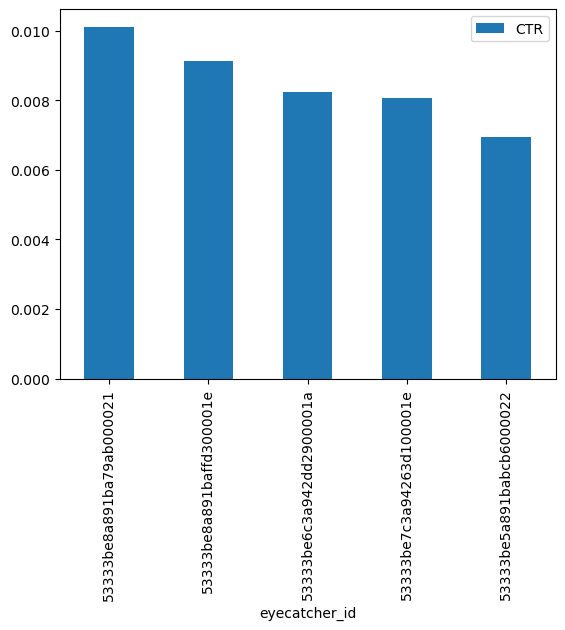

In [66]:
df_confirmatory_exp["CTR"] = df_confirmatory_exp["clicks"] / df_confirmatory_exp["impressions"]

df_confirmatory_exp.sort_values("CTR", ascending=False).plot(
    x="eyecatcher_id",
    y="CTR",
    kind="bar"
)

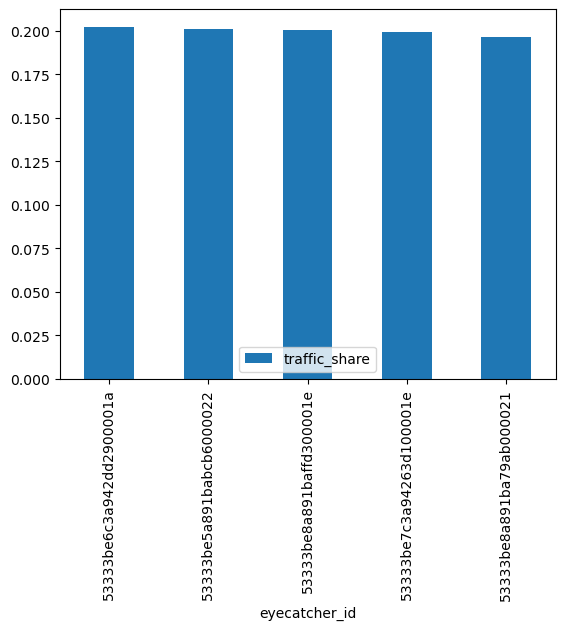

In [67]:

df_confirmatory_exp.sort_values("traffic_share", ascending=False).plot(
    x="eyecatcher_id",
    y="traffic_share",
    kind="bar"
)
plt.savefig('traffic_share_example.png', dpi=200, bbox_inches='tight')

### Sanity checks

In [68]:
# set alpha to use for everything
alpha=0.05

In [69]:
# traffic count per arm 
df_confirmatory_exp["traffic_share"]=df_confirmatory_exp["impressions"]/df_confirmatory_exp["impressions"].sum()
df_confirmatory_exp
for arm in df_confirmatory_exp["eyecatcher_id"].unique():
    print(f"Percentage of users in group,{arm}, is {df_confirmatory_exp[df_confirmatory_exp['eyecatcher_id']==arm]['traffic_share'].item()} ")

Percentage of users in group,53333be5a891babcb6000022, is 0.20112812248186945 
Percentage of users in group,53333be6c3a942dd2900001a, is 0.20236368520010745 
Percentage of users in group,53333be7c3a94263d100001e, is 0.19951651893634165 
Percentage of users in group,53333be8a891ba79ab000021, is 0.19656191243620735 
Percentage of users in group,53333be8a891baffd300001e, is 0.20042976094547407 


#### Sample Ratio Mismatch (SRM)

#### chi square

In [70]:
# number of arms
nums_arm=df_confirmatory_exp["eyecatcher_id"].nunique()
# make obersved number of impressions for chi test
observed=df_confirmatory_exp["impressions"].unique().tolist()
# make total impressions chi test. remember you need to divide by the number of arm
total_impressions=df_confirmatory_exp["impressions"].sum()
expected = [total_impressions/nums_arm]*nums_arm
# run chisquare
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# 3. Print the results
print(f"Chi-Square Statistic : {chi2_stat:.3f}")
print(f"P-value              : {p_value:.3e}")


# 4. Evaluate significance
alpha =alpha
if p_value < alpha:
    print("\nResult: Statistically significant. Reject the null hypothesis. At least one group differs.")
else:
    print("\nResult: Not statistically significant. Fail to reject the null hypothesis.")


Chi-Square Statistic : 1.778
P-value              : 7.766e-01

Result: Not statistically significant. Fail to reject the null hypothesis.


(np.float64(1.7775987107171636), np.float64(0.7765781559612975))

**If your test fails stop right here because there is a selection bias**

#### A/A test

Because the Upworthy dataset is historical and already aggregated, a true A/A test cannot be performed after the fact. A true A/A test requires random assignment of users to identical experiences during data collection. However, I performed SRM checks across variants to test whether the observed impression counts were consistent with the expected traffic allocation.

#### Simpsons Paradox

This applies when you are the same arm, but something else is changing too. In order to invoke simpsons paradox, for an experiment, 2 or more arms that are split into subgroups. ie eyecatcher A has two different word_count_headline and eyecatcher B has also word_count_headline.<br>
In this current example, I can't invoke simpsons paradox because nothing changes in each eyecatcher. Perhaps I can there might be experiment this is not the case.

### Hypothesis testing

#### size effect calculation

In [74]:
#df_exp["ctr"] = df_exp["clicks"] / df_exp["impressions"]

# always select the min
control_ctr = df_confirmatory_exp["CTR"].min()

df_confirmatory_exp["absolute_lift_vs_control"] = df_confirmatory_exp["CTR"] - control_ctr

df_confirmatory_exp["relative_lift_vs_control"] = ( df_confirmatory_exp["CTR"] - control_ctr) / control_ctr

df_confirmatory_exp["cohens_h_vs_control_eff_size"] = df_confirmatory_exp["CTR"].apply( lambda p: proportion_effectsize(p, control_ctr))
df_confirmatory_exp.sort_values(by='relative_lift_vs_control', ascending=True, inplace=True)

#df_exp[["eyecatcher_id","impressions", "clicks", "ctr", "absolute_lift_vs_control","relative_lift_vs_control","cohens_h_vs_control"]].sort_values("ctr", ascending=False)

In [75]:
df_confirmatory_exp

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,...,CTR,word_count_headline,num_count_headline,word_num_count_headline,any_questions,any_number,traffic_share,absolute_lift_vs_control,relative_lift_vs_control,cohens_h_vs_control_eff_size
13534,confirmatory,19396.0,2014-03-26 20:43:45.828,2016-04-02 16:25:20.722,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-2,53333be5a891babcb6000022,...,0.006944,7,0,7,1,0,0.201128,0.000000,0.000000,0.000000
13536,confirmatory,19398.0,2014-03-26 20:44:02.546,2016-04-02 16:25:20.727,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-4,53333be7c3a94263d100001e,...,0.008078,7,0,7,1,0,0.199517,0.001133,0.163166,0.013133
13535,confirmatory,19397.0,2014-03-26 20:43:53.462,2016-04-02 16:25:20.724,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-3,53333be6c3a942dd2900001a,...,0.008229,7,0,7,1,0,0.202364,0.001285,0.185028,0.014821
56438,confirmatory,80691.0,2014-03-26 20:44:22.059,2016-04-02 16:28:43.286,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-6,53333be8a891baffd300001e,...,0.009113,7,0,7,1,0,0.200430,0.002168,0.312249,0.024353
56437,confirmatory,80690.0,2014-03-26 20:44:10.765,2016-04-02 16:28:43.283,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-5,53333be8a891ba79ab000021,...,0.010112,7,0,7,1,0,0.196562,0.003168,0.456136,0.034598


**Guide for Cohen's h effect size**
* Small effect =0.2
* Medium effect =0.5
* Large effect =0.8

In my example, the cohen's effect size is small meaning that effect of this variant over the control is neglgible. <br>
Even the relative uplight is high, we can'

#### Sample Size calcuation or Check

Since this experiment was already completed, the sample size calculation is not used to plan data collection. Instead, it is used as a diagnostic check to evaluate whether the observed sample size was large enough to reliably detect a practically meaningful lift in click-through rate

For sample size checking, p_variant_target should be the minimum effect you would care about detecting. I have set the minimum_detectable_lift  to be the max of the df_confirmatory_exp["relative_lift_vs_control"]. This is done to try to make the required sample size smaller. <br>
I have also removed the Bonferroni penalty.<br>


In [76]:

control_ctr=df_confirmatory_exp["CTR"].min()   # control 0 lift

minimum_detectable_lift = df_confirmatory_exp["relative_lift_vs_control"].max()   #  using the max of the data to get the uplift to get to.

p_variant_target = control_ctr * (1 + minimum_detectable_lift)

effect_size = proportion_effectsize(p_variant_target, control_ctr)


power_analysis = NormalIndPower()

required_n_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=alpha,
    ratio=1,
    alternative="larger"
)

(required_n_per_group,effect_size)

(10330.060043022406, np.float64(0.034597733381210055))

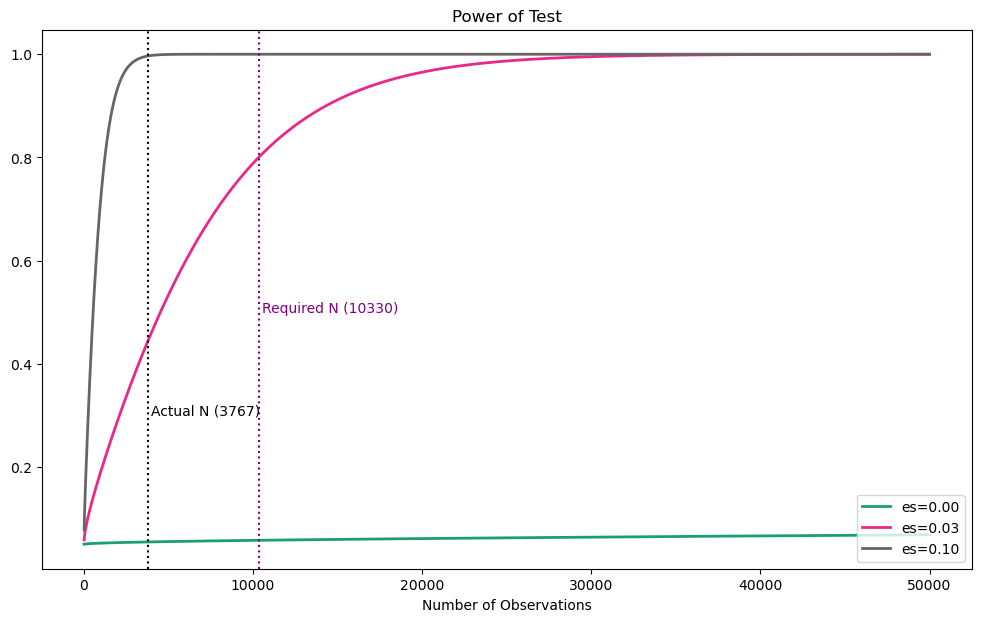

In [78]:
# Specify parameters for power analysis
fig, ax = plt.subplots(figsize=(12, 7))
sample_sizes = np.array(range(10, 50000))
effect_sizes = np.array([0.001, effect_size, 0.1])

power_analysis.plot_power(
    nobs=sample_sizes, 
    effect_size=effect_sizes, 
    alternative="larger", 
    alpha=alpha, 
    ratio=1, 
    ax=ax
)

# Reference lines
plt.axvline(x=required_n_per_group, color="purple", linestyle=":")
plt.text(required_n_per_group + 200, 0.5, f"Required N ({int(required_n_per_group)})", color="purple")

actual_per_group = df_confirmatory_exp["impressions"].max()
plt.axvline(x=actual_per_group, color="black", linestyle=":")
plt.text(actual_per_group + 200, 0.3, f"Actual N ({int(actual_per_group)})", color="black")
plt.savefig('power_plot.png', dpi=200, bbox_inches='tight')



#### Hypothesis testing

The goal is to find which variant is the best. I am testing that the variant CTR is less or equal to the control CTR.  that is my null hypothesis, so I use a one-sided (upper-tailed) test (alternative="greater"). Furthermore, I am comparing many variant to one comparison. <br> 
The Dunnet test is best for testing many variants to one.<br>

If Dunnett's test reveals that both Variant 4 and Variant 5 are statistically significant winners over the control, it won't explicitly tell you if Variant 4 is significantly better than Variant 5.<br>

To confidently declare the absolute best variant among the winners, you would look at the point estimates (the actual observed CTRs) and their confidence intervals. If the confidence intervals of your top two variants heavily overlap, they are effectively performing at a similar tier.


Null Hypothesis ($H_0$): $\text{CTR}_{\text{variant } i} \le \text{CTR}_{\text{control}}$ <br> (The variant's click-through rate is less than or equal to the control; there is no positive improvement.)<br>

Alternative Hypothesis ($H_A$): $\text{CTR}_{\text{variant } i} > \text{CTR}_{\text{control}}$ <br> (The variant's click-through rate is strictly greater than the control.)

In [80]:
df_confirmatory_exp

,dataset_id,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,...,CTR,word_count_headline,num_count_headline,word_num_count_headline,any_questions,any_number,traffic_share,absolute_lift_vs_control,relative_lift_vs_control,cohens_h_vs_control_eff_size
13534,confirmatory,19396.0,2014-03-26 20:43:45.828,2016-04-02 16:25:20.722,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-2,53333be5a891babcb6000022,...,0.006944,7,0,7,1,0,0.201128,0.000000,0.000000,0.000000
13536,confirmatory,19398.0,2014-03-26 20:44:02.546,2016-04-02 16:25:20.727,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-4,53333be7c3a94263d100001e,...,0.008078,7,0,7,1,0,0.199517,0.001133,0.163166,0.013133
13535,confirmatory,19397.0,2014-03-26 20:43:53.462,2016-04-02 16:25:20.724,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-3,53333be6c3a942dd2900001a,...,0.008229,7,0,7,1,0,0.202364,0.001285,0.185028,0.014821
56438,confirmatory,80691.0,2014-03-26 20:44:22.059,2016-04-02 16:28:43.286,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-6,53333be8a891baffd300001e,...,0.009113,7,0,7,1,0,0.200430,0.002168,0.312249,0.024353
56437,confirmatory,80690.0,2014-03-26 20:44:10.765,2016-04-02 16:28:43.283,51436064220cb8000200034a,Does anyone else's pancreas feel broken today?,Candy Has Less Sugar Than A Sandwich?,<p>Sugar in high doses can have very negative ...,candy-has-less-sugar-than-a-sandwich-5,53333be8a891ba79ab000021,...,0.010112,7,0,7,1,0,0.196562,0.003168,0.456136,0.034598


In [81]:
#alpha=0.05

In [82]:
# make alhpa string to use for column header f"Significant (α={alpha})?"
alpha_significant_str=f"Significant (α={alpha})?"
alpha_significant_str

'Significant (α=0.05)?'

In [86]:
#Isolate control and variant rows
control_row = df_confirmatory_exp[df_confirmatory_exp["absolute_lift_vs_control"] == 0]
#variants_df = df_confirmatory_exp[df_confirmatory_exp["absolute_lift_vs_control"] != 0].copy()
variants_df = df_confirmatory_exp.copy()  # I added the control here as variant. So variants_df has everything.

#Reconstruct raw binary arrays (1 for click, 0 for no click)
# Dunnett's test requires the underlying distributions to compute variance
def reconstruct_observations(clicks, total_impressions):
    clicks = int(clicks)
    no_clicks = int(total_impressions - clicks)
    return np.concatenate([np.ones(clicks), np.zeros(no_clicks)])

control_obs = reconstruct_observations(control_row["clicks"].item(), control_row["impressions"].item())

variant_samples = []
variant_id = []

for idx, row in variants_df.iterrows():
    obs = reconstruct_observations(row["clicks"], row["impressions"])
    variant_samples.append(obs)
    variant_id.append(row["eyecatcher_id"])
    

#Execute Dunnett's Test
# We unpack the variant arrays. alternative='greater' looks for Variant > Control.
res = dunnett(*variant_samples, control=control_obs, alternative="greater")

#Extract and format the results
results = []
for i, eyecatcher__id in enumerate(variant_id):
    # Dunnett's test summary outputs statistics in order of passed variants
    statistic = res.statistic[i]
    p_value = res.pvalue[i]
    
    # Extract corresponding data row for reporting
    v_row = variants_df[variants_df["eyecatcher_id"] == eyecatcher__id].iloc[0]
    
    results.append({
        "Variant (eyecatcher_id)": eyecatcher__id,
        "Variant CTR %": round(v_row['CTR']*100,3),
        "Relative Lift %": round(v_row['relative_lift_vs_control']*100,3),
        "Dunnett Statistic": round(statistic, 3),
        "Adjusted p-value": round(p_value,3),
        alpha_significant_str: "YES" if p_value < alpha else "NO"
    })
 # put result in dataframe
df_dunnett_results = pd.DataFrame(results)

# for CI calculation
results_with_ci=[]
for idx, row in df_confirmatory_exp.iterrows():
    clicks = int(row["clicks"])
    impressions = int(row["impressions"])
    
    # Calculate the 95% confidence interval (alpha=0.05)
    # The 'normal' method uses the standard Wald interval, 
    # but 'wilson' or 'agresti-coull' are great alternative methods for low proportions.
    ci_lower, ci_upper = proportion_confint(count=clicks, nobs=impressions, alpha=alpha, method='wilson')
    
    results_with_ci.append({
        "Variant (eyecatcher_id)": row["eyecatcher_id"],
        "Is Control?": "YES" if row["absolute_lift_vs_control"] == 0 else "NO",
        "CI Lower Bound %": round(ci_lower*100,3),
        "CI Upper Bound %": round(ci_upper*100,3)
    })
# Convert to DataFrame for a clean view
df_ci_summary = pd.DataFrame(results_with_ci)


# merge the two columns
df_final_result= pd.merge(df_dunnett_results, df_ci_summary, on='Variant (eyecatcher_id)')


In [87]:
df_final_result

,Variant (eyecatcher_id),Variant CTR %,Relative Lift %,Dunnett Statistic,Adjusted p-value,Significant (α=0.05)?,Is Control?,CI Lower Bound %,CI Upper Bound %
0,53333be5a891babcb6000022,0.694,0.000,0.000,0.834,NO,YES,0.474,1.016
1,53333be7c3a94263d100001e,0.808,16.317,0.542,0.627,NO,NO,0.566,1.151
2,53333be6c3a942dd2900001a,0.823,18.503,0.616,0.593,NO,NO,0.580,1.166
3,53333be8a891baffd300001e,0.911,31.225,1.038,0.397,NO,NO,0.653,1.271
4,53333be8a891ba79ab000021,1.011,45.614,1.508,0.209,NO,NO,0.735,1.391


In [88]:

# if rows are significant order by Relative Lift
df_final_result[df_final_result[alpha_significant_str]=="YES"].sort_values(by='Relative Lift %')


,Variant (eyecatcher_id),Variant CTR %,Relative Lift %,Dunnett Statistic,Adjusted p-value,Significant (α=0.05)?,Is Control?,CI Lower Bound %,CI Upper Bound %


#### Plot

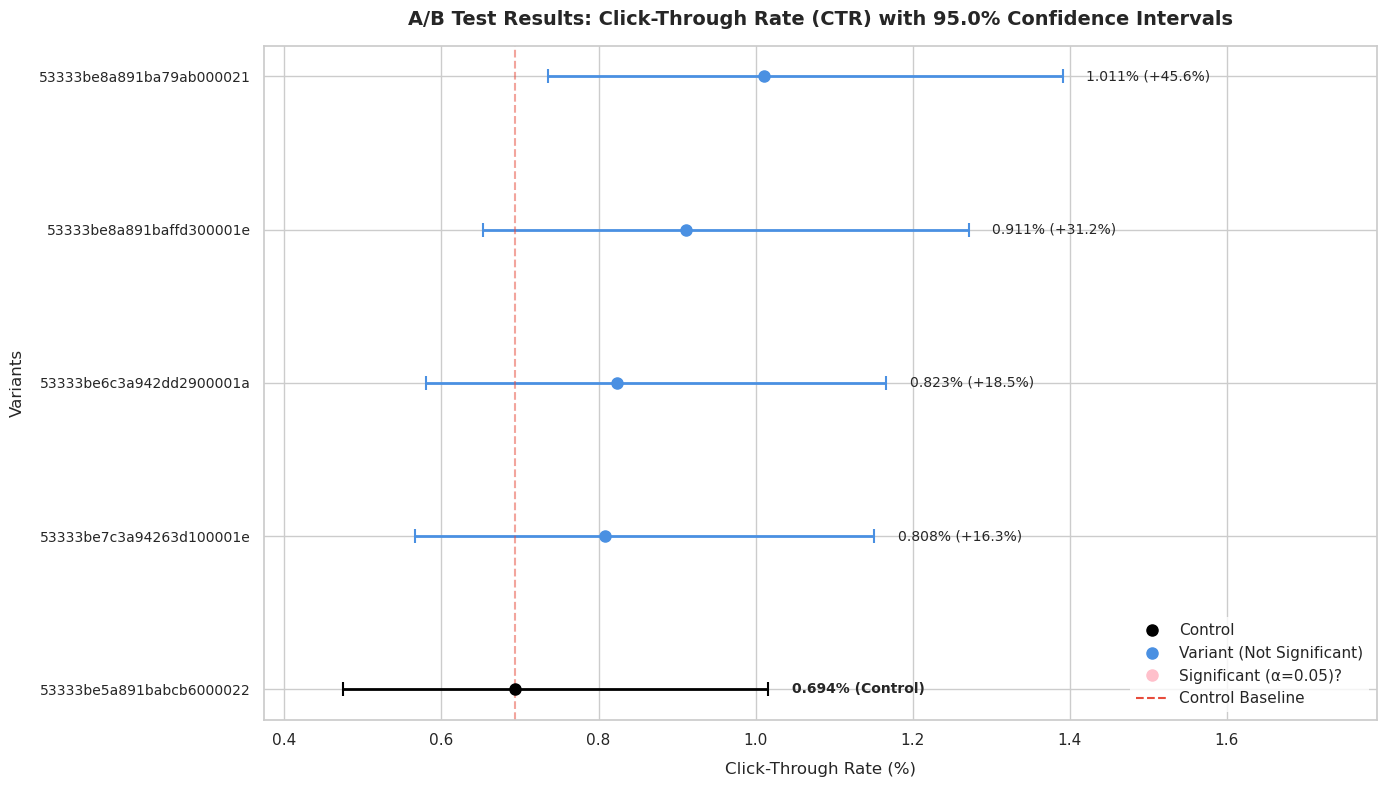

In [90]:
# Calculate the directional error bar lengths
df_final_result['error_left'] = df_final_result['Variant CTR %'] - df_final_result['CI Lower Bound %']
df_final_result['error_right'] = df_final_result['CI Upper Bound %'] - df_final_result['Variant CTR %']

# Sort dataframe by CTR so the best performing headlines naturally rise to the top
df_final_result = df_final_result.sort_values(by='Variant CTR %', ascending=True).reset_index(drop=True)

#Apply a clean design style
sns.set_theme(style="whitegrid")
plt.rc('font', family='sans-serif', size=11)

# Initialize the plot 
fig, ax = plt.subplots(figsize=(14, 8))

# Use distinct coloring to clearly isolate the Control group from the Variants
colors = [
    'pink' if row[alpha_significant_str] == "YES" else
    '#4A90E2' if row['Relative Lift %'] != 0 else
    'black' for _, row in df_final_result.iterrows()]

#Plot points and confidence intervals
for i, row in df_final_result.iterrows():
    ax.errorbar(
        x=row['Variant CTR %'], 
        y=i, 
        xerr=[[row['error_left']], [row['error_right']]], 
        fmt='o', 
        color=colors[i], 
        markersize=8, 
        capsize=5, 
        capthick=1.5, 
        linewidth=2,
        label='Variants' if row['Relative Lift %'] != 0 else 'Control'
    )
        # Add inline text descriptions showing exact performance numbers
    if row['Relative Lift %'] != 0:
        label_text = f"{row['Variant CTR %']:.3f}% (+{row['Relative Lift %']:.1f}%)"
    else:
        label_text = f"{row['Variant CTR %']:.3f}% (Control)"
        
    ax.text(
        row['CI Upper Bound %'] + 0.03, 
        i, 
        label_text,
        va='center', 
        fontsize=10, 
        fontweight='bold' if row['Relative Lift %'] == 0 else 'normal'
    )

# Clean up y-labels to combine the readable slug and backend ID
y_labels = [f"{row['Variant (eyecatcher_id)']}" for _, row in df_final_result.iterrows()]
ax.set_yticks(range(len(df_final_result)))
ax.set_yticklabels(y_labels, fontsize=10)

#Draw a vertical reference line for the Control Baseline
control_ctr = df_final_result[df_final_result['Relative Lift %'] == 0]['Variant CTR %'].values[0]
ax.axvline(x=control_ctr, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.5, label='Control Baseline') # this alpha is to control the color

# Formatting Labels, Limits, and Titles
ax.set_title(f"A/B Test Results: Click-Through Rate (CTR) with {(1-alpha)*100}% Confidence Intervals", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Click-Through Rate (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Variants", fontsize=12, labelpad=10)
ax.set_xlim(df_final_result['CI Lower Bound %'].min() - 0.1, df_final_result['CI Upper Bound %'].max() + 0.4)

# ==========================================
# UPDATED LEGEND HANDLING (CUSTOM HANDLES)
# ==========================================
legend_elements = [
    Line2D([0], [0], marker='o', color='black', label='Control', markersize=8, linestyle='None'),
    Line2D([0], [0], marker='o', color='#4A90E2', label='Variant (Not Significant)', markersize=8, linestyle='None'),
    Line2D([0], [0], marker='o', color='pink', label=alpha_significant_str, markersize=8, linestyle='None'),
    Line2D([0], [0], color='#E74C3C', linestyle='--', linewidth=1.5, label='Control Baseline')
]

# Apply the explicit legend to the axis
ax.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white', edgecolor='none')

plt.savefig('Confidence_Interval.png', dpi=600, bbox_inches='tight')

plt.tight_layout()
plt.show()



Understanding Your Results (The Overlap Check)
Once you print this table, look closely at the CI Lower Bound and CI Upper Bound columns:

No Overlap (Clear Winner): If Variant A's Lower Bound is higher than Variant B's Upper Bound, their intervals do not touch. You can confidently declare Variant A the superior choice.

Heavy Overlap (Statistical Tie): If the intervals cross over each other significantly, it means that even if one has a higher raw CTR in this sample, they are performing within the same statistical margin. They are practically tied.